# Cenário 1 – Identificação de Vulnerabilidades em Dispositivos IoT

Este notebook gera dados simulados e treina modelos de classificação (Random Forest, SVM e XGBoost) para identificar dispositivos vulneráveis.

In [10]:
import numpy as np
import pandas as pd

np.random.seed(42)

n = 2000

firmware_age = np.random.randint(0, 10, n)
open_ports = np.random.randint(1, 20, n)
weak_password = np.random.binomial(1, 0.4, n)
traffic_mb_day = np.random.normal(1000, 400, n).clip(50, None)
failed_logins = np.random.poisson(5, n)

risk_score = (
    0.35 * firmware_age +
    0.25 * open_ports +
    2.5 * weak_password +
    0.15 * failed_logins +
    np.random.normal(0, 1, n)
)

vulnerable = (risk_score > np.percentile(risk_score, 60)).astype(int)

df = pd.DataFrame({
    'firmware_age': firmware_age,
    'open_ports': open_ports,
    'weak_password': weak_password,
    'traffic_mb_day': traffic_mb_day,
    'failed_logins': failed_logins,
    'vulnerable': vulnerable
})

df.head()

# Verificação do balanceamento das classes
print("Quantidade por classe:")
print(df['vulnerable'].value_counts())

print("\nPercentual por classe:")
print(df['vulnerable'].value_counts(normalize=True) * 100)


Quantidade por classe:
vulnerable
0    1200
1     800
Name: count, dtype: int64

Percentual por classe:
vulnerable
0    60.0
1    40.0
Name: proportion, dtype: float64


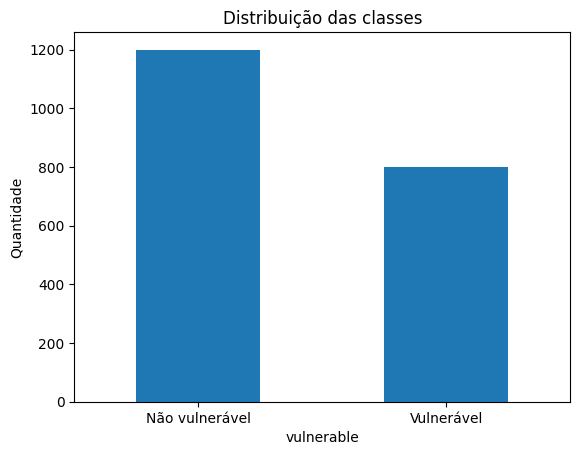

In [11]:
import matplotlib.pyplot as plt

df['vulnerable'].value_counts().sort_index().plot(kind='bar')

plt.xticks([0, 1], ['Não vulnerável', 'Vulnerável'], rotation=0)
plt.ylabel('Quantidade')
plt.title('Distribuição das classes')
plt.show()

In [12]:
from sklearn.model_selection import train_test_split

X = df.drop('vulnerable', axis=1)
y = df['vulnerable']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)


(1400, 5) (600, 5)


In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

# Predições
pred_train_rf = rf.predict(X_train)
pred_test_rf = rf.predict(X_test)

# Accuracy
print("=== RANDOM FOREST ===")
print(f"Accuracy Treino: {accuracy_score(y_train, pred_train_rf):.4f}")
print(f"Accuracy Teste : {accuracy_score(y_test, pred_test_rf):.4f}")

print("\nRelatório - Treino")
print(classification_report(y_train, pred_train_rf))

print("\nRelatório - Teste")
print(classification_report(y_test, pred_test_rf))

=== RANDOM FOREST ===
Accuracy Treino: 1.0000
Accuracy Teste : 0.8400

Relatório - Treino
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       840
           1       1.00      1.00      1.00       560

    accuracy                           1.00      1400
   macro avg       1.00      1.00      1.00      1400
weighted avg       1.00      1.00      1.00      1400


Relatório - Teste
              precision    recall  f1-score   support

           0       0.84      0.90      0.87       360
           1       0.84      0.75      0.79       240

    accuracy                           0.84       600
   macro avg       0.84      0.82      0.83       600
weighted avg       0.84      0.84      0.84       600



In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

svm = Pipeline([    
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='rbf'))
])

svm.fit(X_train, y_train)

pred_svm = svm.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred_svm))
print(classification_report(y_test, pred_svm))


Accuracy: 0.8416666666666667
              precision    recall  f1-score   support

           0       0.85      0.89      0.87       360
           1       0.83      0.77      0.79       240

    accuracy                           0.84       600
   macro avg       0.84      0.83      0.83       600
weighted avg       0.84      0.84      0.84       600



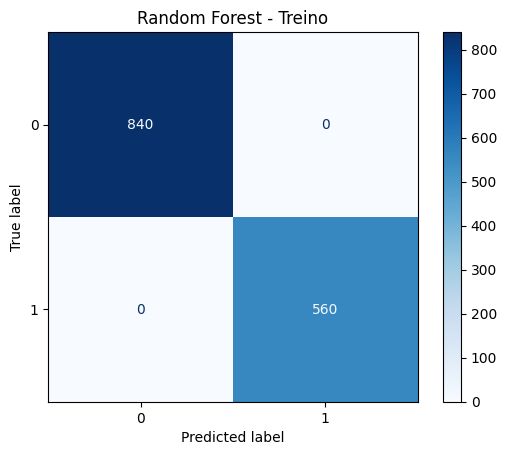

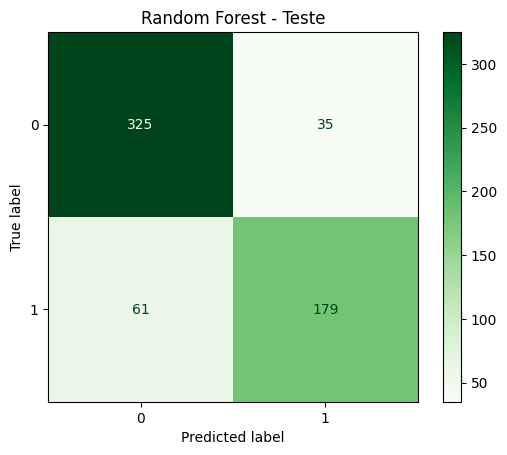

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Treino
ConfusionMatrixDisplay.from_estimator(
    rf,
    X_train,
    y_train,
    cmap="Blues"
)
plt.title("Random Forest - Treino")
plt.show()

# Teste
ConfusionMatrixDisplay.from_estimator(
    rf,
    X_test,
    y_test,
    cmap="Greens"
)
plt.title("Random Forest - Teste")
plt.show()

=== SVM ===
Accuracy Treino: 0.8779
Accuracy Teste : 0.8417

Relatório - Treino
              precision    recall  f1-score   support

           0       0.89      0.91      0.90       840
           1       0.86      0.83      0.84       560

    accuracy                           0.88      1400
   macro avg       0.87      0.87      0.87      1400
weighted avg       0.88      0.88      0.88      1400


Relatório - Teste
              precision    recall  f1-score   support

           0       0.85      0.89      0.87       360
           1       0.83      0.77      0.79       240

    accuracy                           0.84       600
   macro avg       0.84      0.83      0.83       600
weighted avg       0.84      0.84      0.84       600



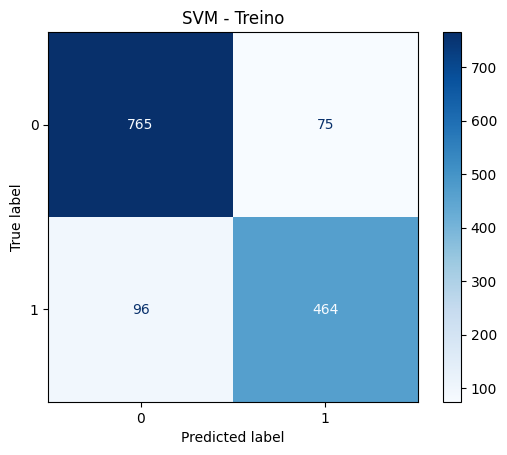

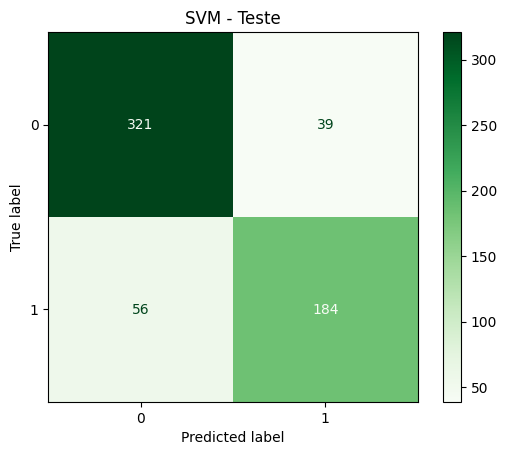

In [15]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

svm = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42))
])

svm.fit(X_train, y_train)

pred_train_svm = svm.predict(X_train)
pred_test_svm = svm.predict(X_test)

print("=== SVM ===")
print(f"Accuracy Treino: {accuracy_score(y_train, pred_train_svm):.4f}")
print(f"Accuracy Teste : {accuracy_score(y_test, pred_test_svm):.4f}")

print("\nRelatório - Treino")
print(classification_report(y_train, pred_train_svm))

print("\nRelatório - Teste")
print(classification_report(y_test, pred_test_svm))

ConfusionMatrixDisplay.from_estimator(svm, X_train, y_train, cmap="Blues")
plt.title("SVM - Treino")
plt.show()

ConfusionMatrixDisplay.from_estimator(svm, X_test, y_test, cmap="Greens")
plt.title("SVM - Teste")
plt.show()

=== XGBOOST ===
Accuracy Treino: 0.9486
Accuracy Teste : 0.8483

Relatório - Treino
              precision    recall  f1-score   support

           0       0.95      0.96      0.96       840
           1       0.94      0.93      0.94       560

    accuracy                           0.95      1400
   macro avg       0.95      0.94      0.95      1400
weighted avg       0.95      0.95      0.95      1400


Relatório - Teste
              precision    recall  f1-score   support

           0       0.86      0.90      0.88       360
           1       0.83      0.78      0.80       240

    accuracy                           0.85       600
   macro avg       0.85      0.84      0.84       600
weighted avg       0.85      0.85      0.85       600



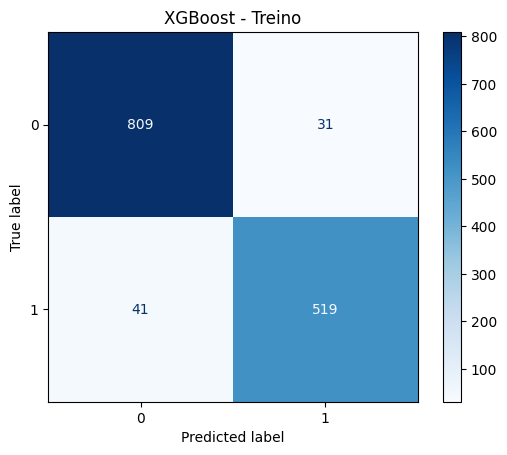

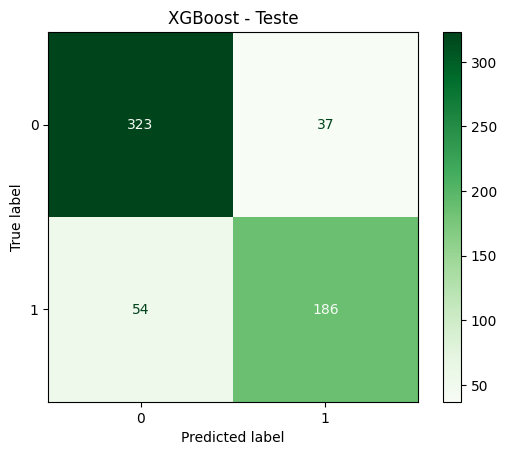

In [16]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train, y_train)

pred_train_xgb = xgb.predict(X_train)
pred_test_xgb = xgb.predict(X_test)

print("=== XGBOOST ===")
print(f"Accuracy Treino: {accuracy_score(y_train, pred_train_xgb):.4f}")
print(f"Accuracy Teste : {accuracy_score(y_test, pred_test_xgb):.4f}")

print("\nRelatório - Treino")
print(classification_report(y_train, pred_train_xgb))

print("\nRelatório - Teste")
print(classification_report(y_test, pred_test_xgb))

ConfusionMatrixDisplay.from_estimator(xgb, X_train, y_train, cmap="Blues")
plt.title("XGBoost - Treino")
plt.show()

ConfusionMatrixDisplay.from_estimator(xgb, X_test, y_test, cmap="Greens")
plt.title("XGBoost - Teste")
plt.show()

In [ ]:
try:
    from xgboost import XGBClassifier

    xgb = XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.1,
        random_state=42,
        eval_metric='logloss'
    )

    xgb.fit(X_train, y_train)

    pred_xgb = xgb.predict(X_test)

    print("Accuracy:", accuracy_score(y_test, pred_xgb))
    print(classification_report(y_test, pred_xgb))

    

except ImportError:
    print("XGBoost não está instalado. Execute: pip install xgboost")


Accuracy: 0.8483333333333334
              precision    recall  f1-score   support

           0       0.86      0.90      0.88       360
           1       0.83      0.78      0.80       240

    accuracy                           0.85       600
   macro avg       0.85      0.84      0.84       600
weighted avg       0.85      0.85      0.85       600



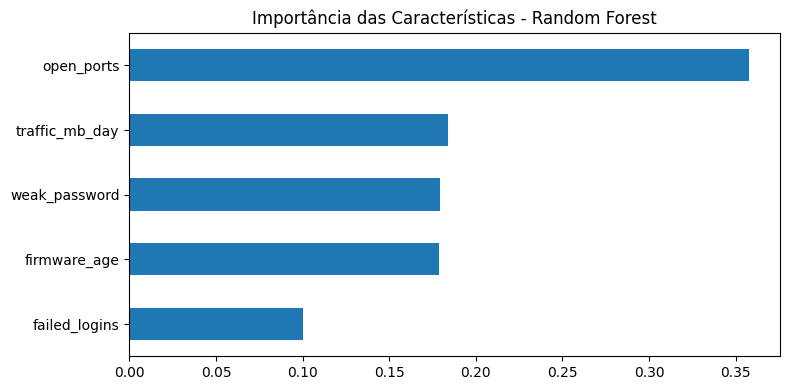

In [7]:
import matplotlib.pyplot as plt

importances = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values()

plt.figure(figsize=(8,4))
importances.plot(kind='barh')
plt.title('Importância das Características - Random Forest')
plt.tight_layout()
plt.show()
